In [2]:
import os
import sys
import json
import warnings
import numpy as np
import pandas as pd
import proplot as pplt
sys.path.insert(0,'..')
from scripts.utils import Config
from scripts.models.sr.train import load_data,subsample_timestep
warnings.filterwarnings('ignore')
pplt.rc.update({'tick.minor':False,'figure.dpi':100})

In [3]:
config    = Config()
RUNNAME   = 'sr_gauss_all'
RUNCONFIG = config.sr['runs'][RUNNAME]
SEEDS     = config.sr['seeds']
SUBFRAC   = config.sr['subsetfrac']
SEED      = SEEDS[0]

In [4]:
def load_split_data():
    xtrain,ytrain,reftrain,vmtrain = load_data('train',RUNCONFIG,config,time_offset=0)
    xvalid,yvalid,_,vmvalid        = load_data('valid',RUNCONFIG,config,time_offset=int(reftrain.sizes['time']))
    xfit = pd.concat([xtrain[vmtrain],xvalid[vmvalid]]).reset_index(drop=True)
    yfit = np.concatenate([ytrain[vmtrain],yvalid[vmvalid]])
    return xfit,yfit

def to_mm(y):
    with open(os.path.join(config.splitsdir,'stats.json'),'r',encoding='utf-8') as f:
        STATS  = json.load(f)
        TPMEAN = STATS[f'{config.targetvar}_mean']
        TPSTD  = STATS[f'{config.targetvar}_std']
    return np.expm1(y*TPSTD+TPMEAN)

def summary_stats(tp):
    return {
        'Samples':f'{len(tp)}',
        'Dry (≤1e-4 mm)':f'{np.mean(tp<=1e-4):.2%}',
        'Mean':f'{np.mean(tp):.3f}',
        'Median':f'{np.median(tp):.3f}',
        '90th Percentile':f'{np.percentile(tp,90):.3f}',
        '99th Percentile':f'{np.percentile(tp,99):.3f}',
        'Max':f'{np.max(tp):.3f}'}
    
def bin_fracs(tp,bins):
    counts = np.array([(tp<=bins[1]).sum()]+[((tp>bins[i])&(tp<=bins[i+1])).sum() for i in range(1,len(bins)-1)])
    return counts/counts.sum()

In [5]:
xfit,yfit = load_split_data()
xsub,ysub = subsample_timestep(xfit,yfit,subsetfrac=SUBFRAC,seed=SEED)
full   = to_mm(yfit)
subset = to_mm(ysub)

In [6]:
fullstats   = summary_stats(full)
subsetstats = summary_stats(subset)
subsetratio = len(subset)/len(full)
subsetstats['Samples'] = f'{len(subset)} ({subsetratio:.3%})'

df = pd.DataFrame({'Full':fullstats,'Subset':subsetstats})
df

,Full,Subset
Samples,8624448,216132 (2.506%)
Dry (≤1e-4 mm),18.99%,19.04%
Mean,0.724,0.727
Median,0.092,0.092
90th Percentile,2.067,2.120
99th Percentile,8.494,8.352
Max,139.407,98.566


In [7]:
BINS   = np.array([0,1e-4,1e-2,1e-1,1,10,100,np.inf])
LABELS = ['Dry (≤1e-4)','(1e-4, 1e-2]','(1e-2, 0.1]','(0.1, 1]','(1, 10]','(10, 100]','>100']

df = pd.DataFrame({'Full Bin Fraction':bin_fracs(full,BINS),'Subset Bin Fraction':bin_fracs(subset,BINS)},index=LABELS)
df

,Full Bin Fraction,Subset Bin Fraction
Dry (≤1e-4),0.189879,0.190388
"(1e-4, 1e-2]",0.106942,0.108397
"(1e-2, 0.1]",0.213736,0.212190
"(0.1, 1]",0.315836,0.311513
"(1, 10]",0.166787,0.171048
"(10, 100]",0.006818,0.006464
>100,0.000002,0.000000


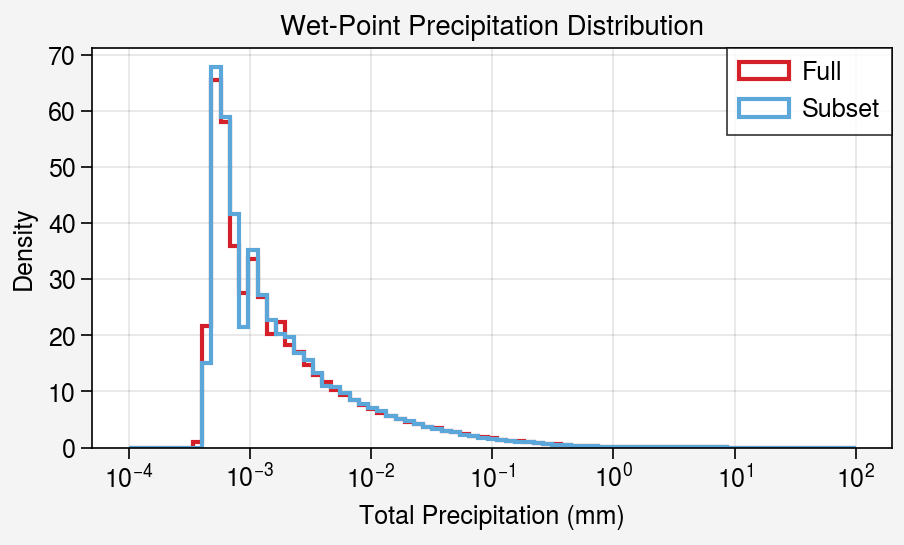

In [8]:
wetfull   = full[full>1e-4]
wetsubset = subset[subset>1e-4]
bins     = np.logspace(-4,2,80)
fig,ax   = pplt.subplots(refwidth=4,refheight=2)
ax.format(xlabel='Total Precipitation (mm)',xscale='log',xformatter='log',
          ylabel='Density',title='Wet-Point Precipitation Distribution',grid=True)
ax.hist(full,bins=bins,density=True,histtype='step',linewidth=1.5,color='#D42028',label='Full')
ax.hist(subset,bins=bins,density=True,histtype='step',linewidth=1.5,color='#5BA7DA',label='Subset')
ax.legend(loc='ur',ncols=1)
pplt.show()

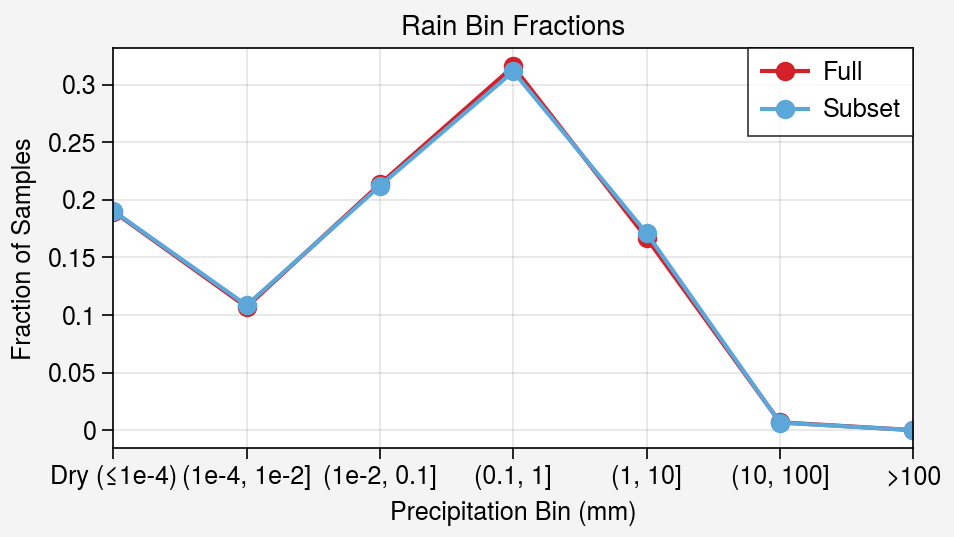

In [9]:
xidx = np.arange(len(LABELS))
fig,ax = pplt.subplots(refwidth=4,refheight=2)
ax.format(title='Rain Bin Fractions',xlabel='Precipitation Bin (mm)',xlocator=xidx,xformatter=LABELS,
          ylabel='Fraction of Samples')
ax.plot(xidx,bin_fracs(full,BINS),color='#D42028',marker='o',label='Full')
ax.plot(xidx,bin_fracs(subset,BINS), color='#5BA7DA',marker='o',label='Subset')
ax.legend(loc='ur',ncols=1)
pplt.show()